In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import files
uploaded = files.upload()

Saving pain_dataset_200P_4hz.csv to pain_dataset_200P_4hz.csv


In [3]:
import io
df = pd.read_csv(io.BytesIO(uploaded['pain_dataset_200P_4hz.csv']))

print(df.shape)

(96000, 9)


In [4]:
print(df.head())

  person_ID   acc_x   acc_y   acc_z     eda     bvp    hr   temp  pain_scale
0      P001  0.2751 -0.0464  0.3049  0.7395   99.24  67.6  33.94           5
1      P001  0.2428 -0.1161  0.3641  0.7793  103.24  68.3  33.95           5
2      P001  0.0146 -0.1479  0.6552  0.8581  103.08  68.1  33.91           5
3      P001 -0.0806 -0.2144  0.6631  0.8881  104.12  66.6  33.94           5
4      P001 -0.0808 -0.1754  0.5448  0.7786  107.05  66.8  33.95           5


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96000 entries, 0 to 95999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   person_ID   96000 non-null  object 
 1   acc_x       96000 non-null  float64
 2   acc_y       96000 non-null  float64
 3   acc_z       96000 non-null  float64
 4   eda         96000 non-null  float64
 5   bvp         96000 non-null  float64
 6   hr          96000 non-null  float64
 7   temp        96000 non-null  float64
 8   pain_scale  96000 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 6.6+ MB
None


In [8]:
print(df.describe())

              acc_x         acc_y         acc_z           eda           bvp  \
count  96000.000000  96000.000000  96000.000000  96000.000000  96000.000000   
mean       0.000359     -0.005374      0.005558      2.890202     86.924307   
std        0.274042      0.274731      0.274240      2.151289     26.516553   
min       -1.249800     -1.025200     -1.211600      0.050000     40.000000   
25%       -0.182800     -0.190400     -0.178500      0.991100     64.290000   
50%        0.000300     -0.005150      0.003400      2.674100     89.130000   
75%        0.184300      0.179300      0.187600      4.464400    109.370000   
max        1.138500      1.171900      1.103000      9.862200    130.000000   

                 hr          temp   pain_scale  
count  96000.000000  96000.000000  96000.00000  
mean      79.270666     34.514430      4.53500  
std       13.785112      1.731756      2.13748  
min       50.000000     30.250000      1.00000  
25%       69.100000     33.320000      3.00

In [9]:
print(df.isnull().sum())

person_ID     0
acc_x         0
acc_y         0
acc_z         0
eda           0
bvp           0
hr            0
temp          0
pain_scale    0
dtype: int64


In [10]:
print(df['pain_scale'].value_counts().sort_index())

pain_scale
1     9600
2     9120
3    13920
4    17280
5    10560
6    16320
7     7680
8    11520
Name: count, dtype: int64


In [11]:
X = df.drop(columns=['person_ID', 'pain_scale'])
y = df['pain_scale']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"\n Training set:  {X_train.shape}")
print(f"Testing set:   {X_test.shape}")


 Training set:  (76800, 7)
Testing set:   (19200, 7)


In [13]:
#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [14]:
#Decision tree => built in library
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [15]:
# 1- create model
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

# 2- train model
dt_model.fit(X_train_scaled, y_train)

# 3- predict model
dt_pred = dt_model.predict(X_test_scaled)

# 4- Results
dt_accuracy = accuracy_score(y_test, dt_pred)

In [16]:
print(f"Accuracy: {dt_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Accuracy: 72.86%

Classification Report:
              precision    recall  f1-score   support

           1       0.79      0.77      0.78      1990
           2       0.68      0.68      0.68      1801
           3       0.69      0.68      0.68      2809
           4       0.71      0.73      0.72      3474
           5       0.68      0.69      0.69      2071
           6       0.76      0.75      0.75      3254
           7       0.70      0.68      0.69      1525
           8       0.82      0.83      0.82      2276

    accuracy                           0.73     19200
   macro avg       0.73      0.73      0.73     19200
weighted avg       0.73      0.73      0.73     19200



In [17]:
#Decision tree from Scratch
class DecisionTreeScratch:
    def __init__(self, max_depth=10):
        self.max_depth = max_depth
        self.tree = None

    def gini(self, y):
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)

    def best_split(self, X, y):
        best_gini = float('inf')
        best_feature = None
        best_threshold = None

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left  = y[X[:, feature] <= threshold]
                right = y[X[:, feature] >  threshold]

                if len(left) == 0 or len(right) == 0:
                    continue

                gini = (len(left)  * self.gini(left) +
                        len(right) * self.gini(right)) / len(y)

                if gini < best_gini:
                    best_gini      = gini
                    best_feature   = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth=0):
        # stopping conditions
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return {'leaf': True,
                    'prediction': np.bincount(y).argmax()}

        feature, threshold = self.best_split(X, y)

        if feature is None:
            return {'leaf': True,
                    'prediction': np.bincount(y).argmax()}

        left_mask  = X[:, feature] <= threshold
        right_mask = X[:, feature] >  threshold

        return {
            'leaf'      : False,
            'feature'   : feature,
            'threshold' : threshold,
            'left'      : self.build_tree(X[left_mask],  y[left_mask],  depth + 1),
            'right'     : self.build_tree(X[right_mask], y[right_mask], depth + 1)
        }

    def fit(self, X, y):
        self.tree = self.build_tree(X, y.to_numpy())
        print("Decision Tree (Scratch) trained!")

    def predict_one(self, x, node):
        if node['leaf']:
            return node['prediction']
        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        return self.predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])


# Train
X_sample = X_train_scaled[:5000]
y_sample = y_train.iloc[:5000]

dt_scratch = DecisionTreeScratch(max_depth=10)
dt_scratch.fit(X_sample, y_sample)

# Predict
dt_scratch_pred = dt_scratch.predict(X_test_scaled[:1000])
dt_scratch_acc  = accuracy_score(y_test.iloc[:1000], dt_scratch_pred)


Decision Tree (Scratch) trained!


In [18]:
print(f"Accuracy: {dt_scratch_acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test.iloc[:1000], dt_scratch_pred))

Accuracy: 42.20%

Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.58      0.56        99
           2       0.36      0.38      0.37        97
           3       0.41      0.43      0.42       150
           4       0.35      0.36      0.36       168
           5       0.34      0.28      0.31       124
           6       0.41      0.53      0.46       168
           7       0.28      0.12      0.17        72
           8       0.65      0.57      0.61       122

    accuracy                           0.42      1000
   macro avg       0.42      0.41      0.41      1000
weighted avg       0.42      0.42      0.42      1000



In [19]:
print(f"Built-in Accuracy : {dt_accuracy * 100:.2f}%")
print(f"Scratch Accuracy  : {dt_scratch_acc * 100:.2f}%")

Built-in Accuracy : 72.86%
Scratch Accuracy  : 42.20%


In [20]:
# Random Forest

#built in model
# 1- create model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=42
)
# 2- Train model
rf_model.fit(X_train_scaled, y_train)

# 3- Predict
rf_pred = rf_model.predict(X_test_scaled)

# 4- Results
rf_accuracy = accuracy_score(y_test, rf_pred)

In [21]:
print(f"Accuracy: {rf_accuracy * 100:.2f}%")
print("\n Classification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 87.41%

 Classification Report:
              precision    recall  f1-score   support

           1       0.88      0.92      0.90      1990
           2       0.88      0.83      0.85      1801
           3       0.85      0.86      0.85      2809
           4       0.84      0.89      0.87      3474
           5       0.89      0.83      0.86      2071
           6       0.87      0.92      0.89      3254
           7       0.93      0.77      0.85      1525
           8       0.91      0.91      0.91      2276

    accuracy                           0.87     19200
   macro avg       0.88      0.87      0.87     19200
weighted avg       0.88      0.87      0.87     19200



In [28]:
class RandomForestScratch:
    def __init__(self, n_trees=10, max_depth=15, max_features='sqrt'):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = X.shape[0]
        y = np.array(y)

        for i in range(self.n_trees):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample = X[indices]
            y_sample = y[indices]

            tree = DecisionTreeScratch(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            print(f"Tree {i+1}/{self.n_trees} done")

    def predict(self, X):
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        final_preds = []
        for col in range(all_preds.shape[1]):
            votes = all_preds[:, col]
            values, counts = np.unique(votes, return_counts=True)
            final_preds.append(values[np.argmax(counts)])
        return np.array(final_preds)

In [29]:
X_sample = X_train_scaled[:10000]
y_sample = y_train.iloc[:10000]

rf_scratch = RandomForestScratch(
    n_trees=10,
    max_depth=15,
    max_features='sqrt'
)
rf_scratch.fit(X_sample, y_sample)

# Predict
rf_scratch_pred = rf_scratch.predict(X_test_scaled[:2000])
rf_scratch_acc = accuracy_score(y_test.iloc[:2000], rf_scratch_pred)

print(f"Built-in Accuracy : {rf_accuracy * 100:.2f}%")
print(f"Scratch Accuracy  : {rf_scratch_acc * 100:.2f}%")

Training Random Forest from Scratch...
Decision Tree (Scratch) trained!
Tree 1/10 done
Decision Tree (Scratch) trained!
Tree 2/10 done
Decision Tree (Scratch) trained!
Tree 3/10 done
Decision Tree (Scratch) trained!
Tree 4/10 done
Decision Tree (Scratch) trained!
Tree 5/10 done
Decision Tree (Scratch) trained!
Tree 6/10 done
Decision Tree (Scratch) trained!
Tree 7/10 done
Decision Tree (Scratch) trained!
Tree 8/10 done
Decision Tree (Scratch) trained!
Tree 9/10 done
Decision Tree (Scratch) trained!
Tree 10/10 done
Built-in Accuracy : 87.41%
Scratch Accuracy  : 55.35%


In [30]:
# Results
rf_builtin_acc = rf_accuracy
rf_scratch_acc = rf_scratch_acc

print(f"Built-in Accuracy : {rf_builtin_acc * 100:.2f}%")
print(f"Scratch Accuracy  : {rf_scratch_acc * 100:.2f}%")


Built-in Accuracy : 87.41%
Scratch Accuracy  : 55.35%


In [31]:
#  Linear Regression - Built-in Library
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Create Model
lr_model = LinearRegression()

# 2. Train Model
lr_model.fit(X_train_scaled, y_train)

# 3. Predict
lr_pred_raw = lr_model.predict(X_test_scaled)
lr_pred     = np.clip(np.round(lr_pred_raw), 1, 8).astype(int)

# 4. Results
lr_accuracy = accuracy_score(y_test, lr_pred)

print(f"Accuracy: {lr_accuracy * 100:.2f}%")

Accuracy: 36.05%


In [32]:
#Linear Regression - From Scratch
class LinearRegressionScratch:
    def __init__(self):
        self.weights = None
        self.bias    = None

    def fit(self, X, y):
        y = np.array(y)
        # Equation W = (X^T X)^-1 X^T y
        X_b = np.c_[np.ones(X.shape[0]), X]
        theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
        self.bias    = theta[0]
        self.weights = theta[1:]
        print("Linear Regression (Scratch) trained!")

    def predict(self, X):
        raw = X @ self.weights + self.bias
        return np.clip(np.round(raw), 1, 8).astype(int)


# Train
lr_scratch = LinearRegressionScratch()
lr_scratch.fit(X_train_scaled, y_train)

# Predict
lr_scratch_pred = lr_scratch.predict(X_test_scaled)
lr_scratch_acc  = accuracy_score(y_test, lr_scratch_pred)

print(f"Accuracy: {lr_scratch_acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_scratch_pred))

Linear Regression (Scratch) trained!
Accuracy: 36.05%

Classification Report:
              precision    recall  f1-score   support

           1       0.67      0.17      0.27      1990
           2       0.31      0.32      0.32      1801
           3       0.33      0.53      0.41      2809
           4       0.36      0.35      0.35      3474
           5       0.26      0.37      0.30      2071
           6       0.44      0.33      0.38      3254
           7       0.22      0.31      0.26      1525
           8       0.78      0.43      0.56      2276

    accuracy                           0.36     19200
   macro avg       0.42      0.35      0.35     19200
weighted avg       0.42      0.36      0.36     19200



In [33]:
lr_builtin_acc = lr_accuracy
lr_scratch_acc = lr_scratch_acc

print(f"Built-in Accuracy : {lr_builtin_acc * 100:.2f}%")
print(f"Scratch Accuracy  : {lr_scratch_acc * 100:.2f}%")

Built-in Accuracy : 36.05%
Scratch Accuracy  : 36.05%


In [34]:
# Logistic Regression - Built-in Library
from sklearn.linear_model import LogisticRegression

# 1. Create Model
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# 2. Train Model
log_model.fit(X_train_scaled, y_train)

# 3. Predict
log_pred = log_model.predict(X_test_scaled)

# 4. Results
log_accuracy = accuracy_score(y_test, log_pred)

print(f"Accuracy: {log_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, log_pred))

Accuracy: 42.61%

Classification Report:
              precision    recall  f1-score   support

           1       0.49      0.67      0.57      1990
           2       0.26      0.09      0.13      1801
           3       0.38      0.37      0.37      2809
           4       0.36      0.51      0.42      3474
           5       0.24      0.04      0.07      2071
           6       0.42      0.59      0.49      3254
           7       0.40      0.15      0.22      1525
           8       0.63      0.73      0.68      2276

    accuracy                           0.43     19200
   macro avg       0.40      0.39      0.37     19200
weighted avg       0.40      0.43      0.39     19200



In [35]:
# Logistic Regression - From Scratch

class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=100):
        self.lr      = lr
        self.epochs  = epochs
        self.weights = {}
        self.bias    = {}
        self.classes = None

    def softmax(self, z):
        e_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return e_z / e_z.sum(axis=1, keepdims=True)

    def fit(self, X, y):
        y            = np.array(y)
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        n_classes    = len(self.classes)

        # Initialize weights
        W = np.zeros((n_features, n_classes))
        b = np.zeros(n_classes)

        # One-hot encode y
        y_onehot = np.zeros((n_samples, n_classes))
        for i, c in enumerate(self.classes):
            y_onehot[:, i] = (y == c).astype(int)

        # Gradient Descent
        for epoch in range(self.epochs):
            z      = X @ W + b
            probs  = self.softmax(z)
            error  = probs - y_onehot
            W     -= self.lr * (X.T @ error) / n_samples
            b     -= self.lr * error.mean(axis=0)

            if (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1}/{self.epochs} done")

        self.W = W
        self.b = b
        print("Logistic Regression (Scratch) trained!")

    def predict(self, X):
        z     = X @ self.W + self.b
        probs = self.softmax(z)
        idx   = np.argmax(probs, axis=1)
        return self.classes[idx]


# Train
print("Training Logistic Regression from Scratch...")

log_scratch = LogisticRegressionScratch(lr=0.01, epochs=100)
log_scratch.fit(X_train_scaled, y_train)

# Predict
log_scratch_pred = log_scratch.predict(X_test_scaled)
log_scratch_acc  = accuracy_score(y_test, log_scratch_pred)

print(f"Accuracy: {log_scratch_acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, log_scratch_pred))

Training Logistic Regression from Scratch...
  Epoch 20/100 done
  Epoch 40/100 done
  Epoch 60/100 done
  Epoch 80/100 done
  Epoch 100/100 done
Logistic Regression (Scratch) trained!
Accuracy: 31.51%

Classification Report:
              precision    recall  f1-score   support

           1       0.25      0.36      0.29      1990
           2       0.00      0.00      0.00      1801
           3       0.27      0.27      0.27      2809
           4       0.29      0.42      0.34      3474
           5       0.00      0.00      0.00      2071
           6       0.30      0.37      0.33      3254
           7       0.00      0.00      0.00      1525
           8       0.42      0.86      0.56      2276

    accuracy                           0.32     19200
   macro avg       0.19      0.28      0.22     19200
weighted avg       0.22      0.32      0.25     19200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [36]:
log_builtin_acc = log_accuracy
log_scratch_acc = log_scratch_acc

print(f"Built-in Accuracy : {log_builtin_acc * 100:.2f}%")
print(f"Scratch Accuracy  : {log_scratch_acc * 100:.2f}%")

Built-in Accuracy : 42.61%
Scratch Accuracy  : 31.51%


In [37]:
# KNN - Built-in Library

from sklearn.neighbors import KNeighborsClassifier

# 1. Create Model
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Train Model
print("Training KNN...")
knn_model.fit(X_train_scaled, y_train)

# 3. Predict
knn_pred = knn_model.predict(X_test_scaled)

# 4. Results
knn_accuracy = accuracy_score(y_test, knn_pred)

print(f"Accuracy: {knn_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

Training KNN...
Accuracy: 67.07%

Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.80      0.74      1990
           2       0.58      0.62      0.60      1801
           3       0.61      0.63      0.62      2809
           4       0.65      0.66      0.66      3474
           5       0.64      0.58      0.61      2071
           6       0.71      0.70      0.71      3254
           7       0.68      0.58      0.62      1525
           8       0.83      0.76      0.80      2276

    accuracy                           0.67     19200
   macro avg       0.67      0.67      0.67     19200
weighted avg       0.67      0.67      0.67     19200



In [38]:
# KNN - From Scratch

class KNNScratch:
    def __init__(self, k=5):
        self.k       = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = np.array(y)
    def predict_one(self, x):
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        k_indices = np.argsort(distances)[:self.k]
        k_labels  = self.y_train[k_indices]
        values, counts = np.unique(k_labels, return_counts=True)
        return values[np.argmax(counts)]

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])


# Train
knn_scratch = KNNScratch(k=5)
knn_scratch.fit(X_train_scaled, y_train)

# Predict
knn_scratch_pred = knn_scratch.predict(X_test_scaled[:500])
knn_scratch_acc  = accuracy_score(y_test.iloc[:500], knn_scratch_pred)

print(f"Accuracy: {knn_scratch_acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test.iloc[:500], knn_scratch_pred))

Accuracy: 64.60%

Classification Report:
              precision    recall  f1-score   support

           1       0.57      0.71      0.63        56
           2       0.56      0.64      0.59        55
           3       0.68      0.63      0.65        81
           4       0.62      0.66      0.64        82
           5       0.67      0.55      0.60        58
           6       0.65      0.66      0.66        74
           7       0.69      0.59      0.63        34
           8       0.79      0.70      0.74        60

    accuracy                           0.65       500
   macro avg       0.65      0.64      0.65       500
weighted avg       0.65      0.65      0.65       500



In [39]:
knn_builtin_acc = knn_accuracy
knn_scratch_acc = knn_scratch_acc

print(f"Built-in Accuracy : {knn_builtin_acc * 100:.2f}%")
print(f"Scratch Accuracy  : {knn_scratch_acc * 100:.2f}%")

Built-in Accuracy : 67.07%
Scratch Accuracy  : 64.60%


In [40]:
#  Native Bytes - Built-in Library
from sklearn.naive_bayes import GaussianNB

# 1. Create Model
nb_model = GaussianNB()

# 2. Train Model
print("Training Naive Bayes...")
nb_model.fit(X_train_scaled, y_train)

# 3. Predict
nb_pred = nb_model.predict(X_test_scaled)

# 4. Results
nb_accuracy = accuracy_score(y_test, nb_pred)

print(f"Accuracy: {nb_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

Training Naive Bayes...
Accuracy: 34.68%

Classification Report:
              precision    recall  f1-score   support

           1       0.34      0.77      0.47      1990
           2       0.09      0.02      0.03      1801
           3       0.26      0.17      0.21      2809
           4       0.32      0.44      0.37      3474
           5       0.26      0.01      0.02      2071
           6       0.34      0.51      0.40      3254
           7       0.38      0.05      0.09      1525
           8       0.53      0.58      0.56      2276

    accuracy                           0.35     19200
   macro avg       0.31      0.32      0.27     19200
weighted avg       0.32      0.35      0.29     19200



In [41]:
# NAIVE BAYES - From Scratch
class NaiveBayesScratch:
    def __init__(self):
        self.classes    = None
        self.mean       = {}
        self.var        = {}
        self.prior      = {}

    def fit(self, X, y):
        y             = np.array(y)
        self.classes  = np.unique(y)
        n_samples     = len(y)

        for c in self.classes:
            X_c          = X[y == c]
            self.mean[c] = X_c.mean(axis=0)
            self.var[c]  = X_c.var(axis=0) + 1e-9
            self.prior[c]= len(X_c) / n_samples

    def gaussian(self, x, mean, var):
        return np.exp(-((x - mean) ** 2) / (2 * var)) / np.sqrt(2 * np.pi * var)

    def predict_one(self, x):
        posteriors = {}
        for c in self.classes:
            likelihood       = np.sum(np.log(self.gaussian(x, self.mean[c], self.var[c])))
            posteriors[c]    = np.log(self.prior[c]) + likelihood
        return max(posteriors, key=posteriors.get)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])


# Train
nb_scratch = NaiveBayesScratch()
nb_scratch.fit(X_train_scaled, y_train)

# Predict
nb_scratch_pred = nb_scratch.predict(X_test_scaled)
nb_scratch_acc  = accuracy_score(y_test, nb_scratch_pred)

print(f"Accuracy: {nb_scratch_acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, nb_scratch_pred))

Accuracy: 34.68%

Classification Report:
              precision    recall  f1-score   support

           1       0.34      0.77      0.47      1990
           2       0.09      0.02      0.03      1801
           3       0.26      0.17      0.21      2809
           4       0.32      0.44      0.37      3474
           5       0.26      0.01      0.02      2071
           6       0.34      0.51      0.40      3254
           7       0.38      0.05      0.09      1525
           8       0.53      0.58      0.56      2276

    accuracy                           0.35     19200
   macro avg       0.31      0.32      0.27     19200
weighted avg       0.32      0.35      0.29     19200



In [42]:
nb_builtin_acc = nb_accuracy
nb_scratch_acc = nb_scratch_acc


print(f"Built-in Accuracy : {nb_builtin_acc * 100:.2f}%")
print(f"Scratch Accuracy  : {nb_scratch_acc * 100:.2f}%")

Built-in Accuracy : 34.68%
Scratch Accuracy  : 34.68%


In [43]:
#Save Results

# Decision Tree
dt_builtin_acc  = dt_accuracy
dt_scratch_acc  = dt_scratch_acc

# Random Forest
rf_builtin_acc  = rf_accuracy
rf_scratch_acc  = rf_scratch_acc

# Linear Regression
lr_builtin_acc  = lr_accuracy
lr_scratch_acc  = lr_scratch_acc


# Logistic Regression
log_builtin_acc = log_accuracy
log_scratch_acc = log_scratch_acc


# KNN
knn_builtin_acc = knn_accuracy
knn_scratch_acc = knn_scratch_acc


# Naive Bayes
nb_builtin_acc  = nb_accuracy
nb_scratch_acc  = nb_scratch_acc


print("All results")
print(f"Decision Tree     : {dt_builtin_acc  * 100:.2f}%")
print(f"Random Forest     : {rf_builtin_acc  * 100:.2f}%")
print(f"Linear Regression : {lr_builtin_acc  * 100:.2f}%")
print(f"Logistic Regression: {log_builtin_acc * 100:.2f}%")
print(f"KNN               : {knn_builtin_acc * 100:.2f}%")
print(f"Naive Bayes       : {nb_builtin_acc  * 100:.2f}%")

All results
Decision Tree     : 72.86%
Random Forest     : 87.41%
Linear Regression : 36.05%
Logistic Regression: 42.61%
KNN               : 67.07%
Naive Bayes       : 34.68%


In [44]:
results = {
    'Model': [
        'Decision Tree', 'Decision Tree',
        'Random Forest', 'Random Forest',
        'Linear Regression', 'Linear Regression',
        'Logistic Regression', 'Logistic Regression',
        'KNN', 'KNN',
        'Naive Bayes', 'Naive Bayes'
    ],
    'Type': [
        'Built-in', 'Scratch',
        'Built-in', 'Scratch',
        'Built-in', 'Scratch',
        'Built-in', 'Scratch',
        'Built-in', 'Scratch',
        'Built-in', 'Scratch'
    ],
    'Accuracy': [
        dt_builtin_acc, dt_scratch_acc,
        rf_builtin_acc, rf_scratch_acc,
        lr_builtin_acc, lr_scratch_acc,
        log_builtin_acc, log_scratch_acc,
        knn_builtin_acc, knn_scratch_acc,
        nb_builtin_acc, nb_scratch_acc
    ]
}

import pandas as pd
df_results = pd.DataFrame(results)
df_results['Accuracy %'] = (df_results['Accuracy'] * 100).round(2)
print(df_results.to_string(index=False))

              Model     Type  Accuracy  Accuracy %
      Decision Tree Built-in  0.728594       72.86
      Decision Tree  Scratch  0.422000       42.20
      Random Forest Built-in  0.874115       87.41
      Random Forest  Scratch  0.553500       55.35
  Linear Regression Built-in  0.360521       36.05
  Linear Regression  Scratch  0.360521       36.05
Logistic Regression Built-in  0.426146       42.61
Logistic Regression  Scratch  0.315052       31.51
                KNN Built-in  0.670677       67.07
                KNN  Scratch  0.646000       64.60
        Naive Bayes Built-in  0.346823       34.68
        Naive Bayes  Scratch  0.346823       34.68


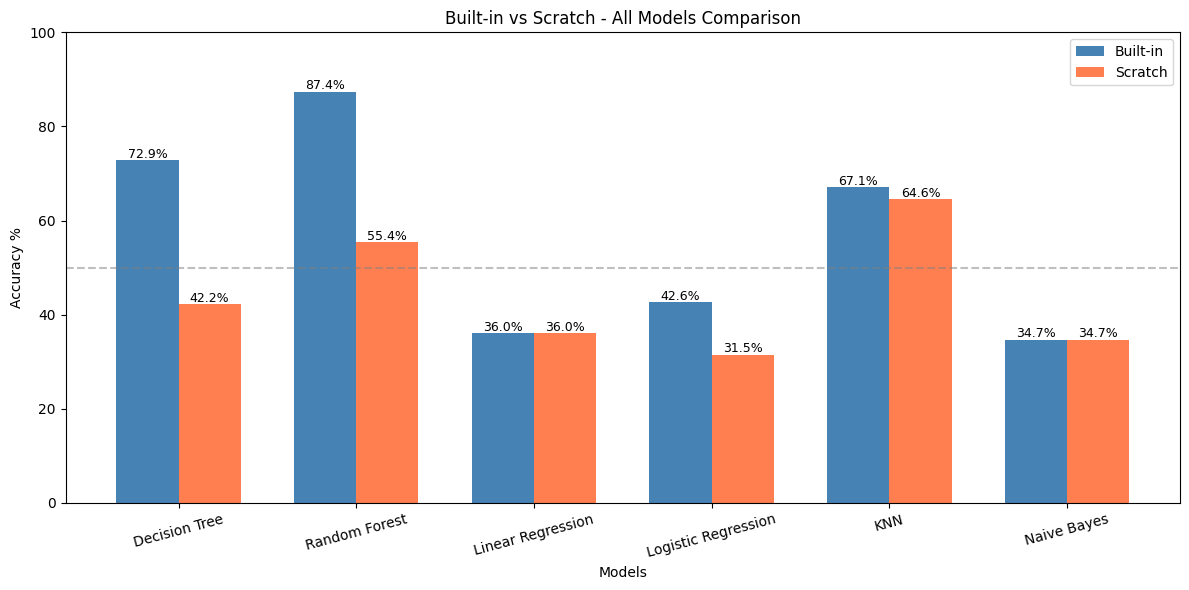

In [45]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Decision Tree', 'Random Forest', 'Linear Regression',
          'Logistic Regression', 'KNN', 'Naive Bayes']

builtin_scores = [72.86, 87.41, 36.05, 42.61, 67.07, 34.68]
scratch_scores = [42.20, 55.35, 36.05, 31.51, 64.60, 34.68]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, builtin_scores, width,
               label='Built-in', color='steelblue')
bars2 = ax.bar(x + width/2, scratch_scores, width,
               label='Scratch', color='coral')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=9)

ax.set_xlabel('Models')
ax.set_ylabel('Accuracy %')
ax.set_title('Built-in vs Scratch - All Models Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0, 100)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()